# Ìmọ̀lára — 03 · Error analysis (test set)

**Models:** AfriBERTa-large (`e4_afriberta_large_final`, seed 42; best on dev) vs the TF-IDF baseline (`e1c_wordchar_lr_final`).
**Data:** AfriSenti Yoruba test split; *clean* = the 4,129 test tweets that do not duplicate a training tweet.

The quantitative findings below come only from **reproducible, objective evidence**: properties of the tweets that can be measured
automatically, statistical label-noise detection, and duplicate-label conflicts. Meaning-based judgements (proverbs, sarcasm, …) appear
only as **illustrative examples, model-assisted and not verified by a native speaker** (see §7 and `results/error_analysis/CODEBOOK.md`).

Everything is produced by `src/error_analysis.py` and `src/label_noise.py`.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import Image, Markdown, display
from src import error_analysis as ea
from src.evaluate import compute_metrics

pd.set_option("display.max_colwidth", 110)
df = ea.add_features(ea.load_predictions())
clean = df[~df["overlap_train"]]
print(f"clean test tweets: {len(clean):,}")
pd.DataFrame({"AfriBERTa": compute_metrics(clean.label_id, clean.pred_model),
              "TF-IDF": compute_metrics(clean.label_id, clean.pred_base)}).T[["accuracy", "macro_f1", "f1_negative", "f1_neutral", "f1_positive"]]

clean test tweets: 4,129


,accuracy,macro_f1,f1_negative,f1_neutral,f1_positive
AfriBERTa,0.7527,0.7374,0.6546,0.7496,0.8081
TF-IDF,0.7568,0.7374,0.6447,0.7506,0.8168


## 1 · Where the errors are: confusion matrices

Both models confuse all three classes with each other; **no single confusion dominates**. Negative, the 22% minority class, has the lowest recall.

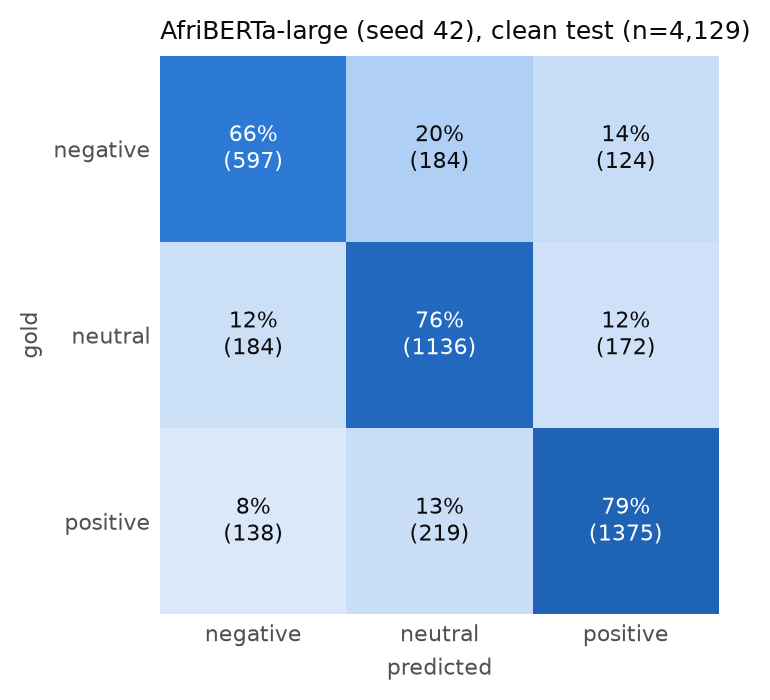

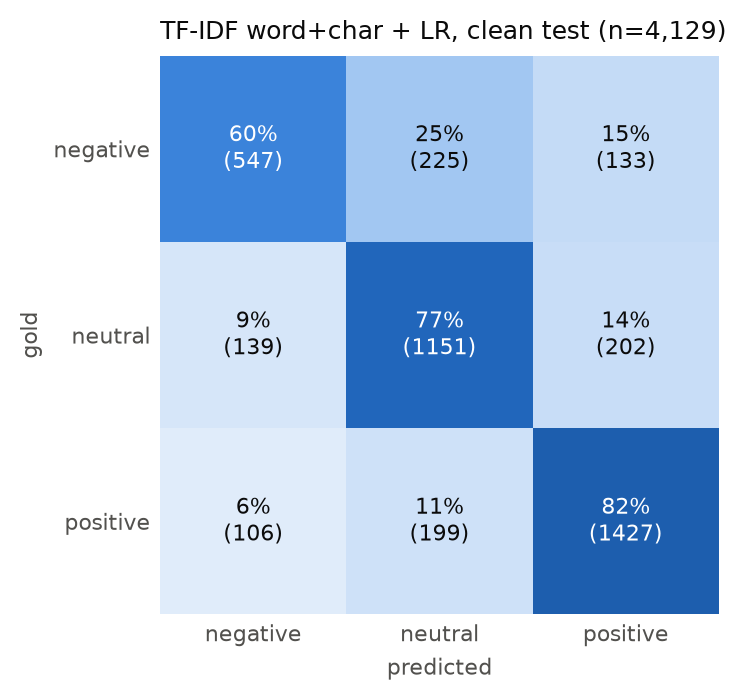

,AfriBERTa errors
positive → neutral,219
neutral → negative,184
negative → neutral,184
neutral → positive,172
positive → negative,138
negative → positive,124


In [2]:
display(Image(str(ROOT / "results/figures/cm_afriberta_test.png"), width=420))
display(Image(str(ROOT / "results/figures/cm_tfidf_test.png"), width=420))
errors = clean[~clean.model_correct]
(errors.gold + " → " + errors.pred_model_label).value_counts().rename("AfriBERTa errors").to_frame()

## 2 · Do the two models fail on the same tweets?

**About two-thirds of AfriBERTa's errors are shared with TF-IDF**: a hard core that neither a bag of n-grams nor a pretrained transformer gets right.
Each model also fixes roughly 360 of the other's errors, so their mistakes are partly complementary.

In [3]:
pd.crosstab(clean.model_correct.map({True: "AfriBERTa right", False: "AfriBERTa wrong"}),
            clean.base_correct.map({True: "TF-IDF right", False: "TF-IDF wrong"}), margins=True)

base_correct,TF-IDF right,TF-IDF wrong,All
model_correct,,,
AfriBERTa right,2755,353,3108
AfriBERTa wrong,370,651,1021
All,3125,1004,4129


## 3 · Objective slices: which kinds of tweet are hard?

* **Code-switching** (≥ 2 English tokens; heuristic detector from `src/eda.py`) costs both models about 5 points.
* **Tweets written without diacritics** cost 5–6 points, consistent with the tone-mark experiments (E6).
* Length matters little; very short tweets are slightly harder for TF-IDF.
* **AfriBERTa is over-confident:** 94% of its predictions have p > 0.9, but those are only about 77% accurate.

In [4]:
for col, title in [("code_switched", "Code-switched"), ("has_diacritics", "Written with diacritics"),
                   ("length_bin", "Length (tokens)"), ("confidence_bin", "AfriBERTa confidence")]:
    display(Markdown(f"**{title}**"))
    display(ea.slice_table(clean, col))

**Code-switched**

,code_switched,n,share,AfriBERTa macro-F1,TF-IDF macro-F1,AfriBERTa accuracy
0,False,3573,86.5%,0.744,0.743,0.761
1,True,556,13.5%,0.690,0.696,0.701


**Written with diacritics**

,has_diacritics,n,share,AfriBERTa macro-F1,TF-IDF macro-F1,AfriBERTa accuracy
0,False,813,19.7%,0.693,0.681,0.720
1,True,3316,80.3%,0.741,0.741,0.761


**Length (tokens)**

,length_bin,n,share,AfriBERTa macro-F1,TF-IDF macro-F1,AfriBERTa accuracy
0,1-5,218,5.3%,0.713,0.670,0.752
1,6-10,698,16.9%,0.708,0.733,0.761
2,11-20,1610,39.0%,0.735,0.720,0.752
3,21-40,1367,33.1%,0.738,0.754,0.748
4,41+,236,5.7%,0.761,0.744,0.763


**AfriBERTa confidence**

,confidence_bin,n,share,AfriBERTa macro-F1,TF-IDF macro-F1,AfriBERTa accuracy
0,<0.5,6,0.1%,0.333,0.656,0.333
1,0.5-0.7,90,2.2%,0.480,0.438,0.478
2,0.7-0.9,154,3.7%,0.483,0.606,0.494
3,>0.9,3879,93.9%,0.754,0.750,0.770


## 4 · Keyword traps

Measured with fixed word lists (`ea.KEYWORDS`). "Errors following the word's polarity" counts AfriBERTa errors where it predicted the word's
usual polarity but the gold label differs.

* **Religious and greeting words** (*Ọlọ́run, Olúwa, àdúrà, ẹ kú…*): 84% of these tweets are positive, so the models learn "God, so positive". About half of
  their errors on such tweets are positive predictions for neutral or negative tweets (e.g. Bible verses labelled neutral).
* **Negative-content words** (*ikú* death, *àrùn* disease, *olè* thief…): about three-quarters of the errors follow the negative word, e.g. positive news about a rescue from Boko Haram.
* **Negation** (*kò, kì í*): both models drop to 0.66–0.69 accuracy (0.75 overall). "Not sweet", "not good" and so on are hard for n-grams and for the transformer alike.

In [5]:
ea.keyword_traps(clean)

,keyword group,tweets,gold neg/neu/pos,AfriBERTa acc.,TF-IDF acc.,errors following the word's polarity
0,religious / greeting words,463,6% / 10% / 84%,0.911 (all: 0.753),0.909,20/41 (49%)
1,"negative-content words (death, disease, thief, wickedness, killing)",86,44% / 19% / 37%,0.744 (all: 0.753),0.744,17/22 (77%)
2,"negation (kò / kì í, diacritised forms only)",439,28% / 32% / 40%,0.692 (all: 0.753),0.663,–


## 5 · Annotation inconsistency (objective): duplicate-label conflicts

386 test tweets duplicate a training tweet (same text after normalisation, ignoring diacritics). **15 of them carry a different gold label**,
and **AfriBERTa predicts the training copy's label in all 15**. These are "errors" caused by the data, not the model. Several are clear-cut:
a condolence ("…it pains me so much I cannot eat") is negative in train but *positive* in test.

In [6]:
summary, examples = ea.duplicate_conflicts(df)
display(summary)
examples

,value
test tweets duplicating a training tweet,386.000
same gold label as the training copy,371.000
different gold label,15.000
AfriBERTa predicts the training copy's label (conflicts),15.000
AfriBERTa accuracy on duplicates,0.956


,train_text,train_label,test_text,test_label,AfriBERTa
8,5. #PariOweYii: irú ẹṣin ní í gbẹ́ṣin ga... #ibeere #Yoruba #Owe,neutral,irú ẹṣin ní í gbẹ́ṣin ga,positive,neutral
1174,"fún àwọn, tí wọ́n ma ṣe àdúrà fún ọmọ náà lórí iṣẹ́ rẹ̀, tí wọ́n sì ma dá èyí tó kù padà fun. Lẹ́yìn owó o...",neutral,fún àwọn tí wọ́n ma ṣe àdúrà fún ọmọ náà lórí iṣẹ́ rẹ̀ tí wọ́n sì ma dá èyí tó kù padà fun lẹ́yìn owó oṣù ...,positive,neutral
1331,RT @user: Ìsé kìí se èsè👊🏿 #oroisiti #Yoruba https://t.co/iVRWjcdiqB,neutral,ìsé kìí se èsè,positive,neutral
1831,"Aku ara fẹra ku ẹni rere to lọ, o dunmi debipe mio le jẹun. Ẹnu mi òsí 😢 https://t.co/TfjGDkpZiq",negative,aku ara fẹra ku ẹni rere to lọ o dunmi debipe mio le jẹun ẹnu mi òsí,positive,negative
2353,Ọláònípẹ̀kun; ọlá = wealth; ò ní = has no; ìpẹ̀kun = end | wealth has no end. Orúkọ Yoòbá @user #Yoruba #Name,positive,ọláònípẹ̀kun ọlá = wealth ò ní = has no ìpẹ̀kun = end | wealth has no end orúkọ yoòbá,neutral,positive
2742,Ajá mọ ọmọ tirẹ̀ í fún lọ́mú; ó mọ ti odù ọ̀yà í kì mọ́lẹ̀. Kíni odù ọ̀yà? #ibeere #Yoruba #Owe,negative,ajá mọ ọmọ tirẹ̀ í fún lọ́mú ó mọ ti odù ọ̀yà í kì mọ́lẹ̀ kíni odù ọ̀yà,neutral,negative
2756,RT @user: Orí tí yóò la 'ni kì í dẹ́rù pa' ni. #EsinOro🐎 #Yoruba,positive,orí tí yóò la ni kì í dẹ́rù pa ni,neutral,positive
2764,@user @user @user Somebody should pay for me. Kí la wà fúnra wa fún 🤷‍♀️,positive,somebody should pay for me kí la wà fúnra wa fún ‍️,neutral,positive
2790,Apá kejì #OgunDahomeyAtiEgba di ọjọ́ mìíràn ọjọ́ ire. A ti d'Óṣòdì.,positive,apá kejì di ọjọ́ mìíràn ọjọ́ ire a ti dóṣòdì,neutral,positive
2939,"RT @user: Ọmọ ọ̀lẹ làyè ò lè gbà, ibi gbogbo ló gba alágbára. / Only a lazy person has issues coping, ever...",positive,ọmọ ọ̀lẹ làyè ò lè gbà ibi gbogbo ló gba alágbára only a lazy person has issues coping every situation sui...,neutral,positive


## 6 · Statistical label-noise estimate (confident learning)

Following Northcutt, Jiang & Chuang (2021), out-of-fold probabilities from 5-fold cross-validation of the TF-IDF model flag tweets whose label a
held-out model confidently contradicts (`src/label_noise.py`). **About 11% of training tweets (14% of negatives) are flagged**, and about 9–10% of dev and test.
This fits the annotators' moderate agreement (free-marginal κ = 0.65; Muhammad et al., 2023) and suggests that roughly 10% of the remaining
error is not reachable by any model trained on these labels. Flags are *candidates* (label error **or** genuinely ambiguous tweet), not proof.

In [7]:
display(Markdown((ROOT / "results/error_analysis/label_noise.md").read_text().split("## Reading-based")[0]))
issues = pd.read_csv(ROOT / "results/error_analysis/label_issues_train.csv")
issues[["text", "label", "confident_class", "p_given", "p_confident"]].head(8)

# Statistical label-noise estimate (confident learning)

_Generated by `python -m src.label_noise`. Method: Northcutt, Jiang & Chuang (2021), confident learning; out-of-fold probabilities from 5-fold cross-validation of the E1c TF-IDF model. A flag means a held-out model is confidently in favour of a different class than the annotators chose. It marks a **candidate** label error (or a genuinely ambiguous tweet), not proof._

Per-class thresholds t_j (mean self-confidence): negative 0.493, neutral 0.642, positive 0.726

## Confident joint on the training set (rows: given label, columns: confident class)

| given label   |   negative |   neutral |   positive |
|:--------------|-----------:|----------:|-----------:|
| negative      |        943 |       186 |         76 |
| neutral       |        211 |      1753 |        118 |
| positive      |        143 |       185 |       2153 |

**Estimated share of training tweets with a likely label issue: 10.8%** (919 of 8,522). For comparison, the AfriSenti annotators' agreement on Yoruba is κ = 0.65.

Flag rate by given label: negative 14.0%, neutral 10.6%, positive 9.3%

- dev: 10.0% of tweets flagged (208 of 2,090)
- test: 9.4% of tweets flagged (423 of 4,515)



,text,label,confident_class,p_given,p_confident
0,ikoja aye ni itumo e yorùbá bọ̀ ilá ti ga ju onírè lọ ọmọ yoòbá kí ni onírè kíni ìtumọ̀ òwe yìí,negative,neutral,0.0030,0.9915
1,ọ̀pẹ̀kẹ́tẹ̀ ńdàgbà inú ádámọ̀ ńbàjẹ́ kí ni ọ̀pẹ̀kẹ́tẹ̀,negative,neutral,0.0032,0.9886
2,iya mi bo si iyara idana ko se iresi fun gbogbo wa emi mo bo mo te phone mi lowo iya mi,neutral,positive,0.0052,0.9762
3,ìgbéyàwóo bánkọ́lé àti adétóun lárinrin wọ́n múlé pọntí wọ́n mọ́nà rokà kí ni múlé pọntí kíni mọ́nà rokà,positive,neutral,0.0058,0.9700
4,ṣe ẹ gbádùn,negative,positive,0.0125,0.9696
5,ariwo tó ta gèè nípa ti re lẹ̀ oti o ko ti re le lai ti ri awon odobinrin wa ẹ rò bẹ́ẹ̀,neutral,negative,0.0093,0.9641
6,sábàbí aáwọ̀ àárín in ifẹ̀ àti modákẹ́kẹ́ aago,negative,neutral,0.0143,0.9676
7,ká yọ ti ọkọ̀ kúrò epo rọ̀bì ni a fi ń tan mànàmáná ṣàṣà nilé tí ò sí ẹ̀rọ amúnáwá kò sí bí ó ti lè kéré tó,neutral,negative,0.0175,0.9696


## 7 · Illustrative examples (model-assisted reading, not verified by a native speaker)

The 100 sampled errors were tagged with the categories in `CODEBOOK.md` (`errors_tagged.csv`, with confidence and gloss per row). **These tags have
not been verified by a native speaker.** A check against the confident-learning flags showed that my "likely label noise" tags did not line up with
them (31% vs 31% flagged), so they are used here only as examples of the phenomena behind the numbers above, not as statistics.
A 50-row native-speaker verification sheet (`verification_sheet.csv`, Cohen's κ via `src/tag_agreement.py`) is ready if a reviewer is available.

In [8]:
tags = pd.read_csv(ROOT / "results/error_analysis/errors_tagged.csv")
illustrative = {  # high-confidence rows, one per phenomenon
    "àkàrà tú sépo": "idiom carries the sentiment",
    "mo fẹ́ran orin yen": "clear positive missed (model error)",
    "ní atetekọṣe ọlọrun dá ọrun ati aiye who": "religious keyword trap (Bible verse, gold neutral)",
    "bójú bá farabalè á rímú": "proverb (patience pays), gold positive",
    "òkèòkun kì í dùn": "negation trap inside a well-wishing proverb",
    "lọ́dún ọdún kẹta": "plain historical fact predicted negative",
    "ti se ikede wipe awon omo ogun nijeria": "violent vocabulary, positive news (rescue)",
    "òtútù òórùn òrùlé": "spelling lesson (word list), no sentiment",
}
rows = []
for start, phenomenon in illustrative.items():
    r = tags[tags.normalised_text.str.startswith(start)].iloc[0]
    rows.append({"tweet": r.normalised_text[:90], "gold": r.gold, "AfriBERTa": r.pred_afriberta,
                 "phenomenon": phenomenon, "gloss (model-assisted)": r.notes[:140]})
pd.DataFrame(rows)

,tweet,gold,AfriBERTa,phenomenon,gloss (model-assisted)
0,àkàrà tú sépo,negative,neutral,idiom carries the sentiment,"Idiom 'àkàrà tú sépo' (the bean cake has dissolved in the oil), i.e. plans have fallen apart. Negative mea..."
1,mo fẹ́ran orin yen,positive,neutral,clear positive missed (model error),'mo fẹ́ràn orin yẹn' = 'I like that song'. Unambiguously positive; a clear model error.
2,ní atetekọṣe ọlọrun dá ọrun ati aiye who,neutral,positive,"religious keyword trap (Bible verse, gold neutral)",Bible verse (Genesis 1:1): 'In the beginning God created heaven and earth'. Neutral religious text read as...
3,bójú bá farabalè á rímú,positive,negative,"proverb (patience pays), gold positive",Proverb 'bójú bá farabalẹ̀ á rímú': if the eye is patient it will see the nose (patience pays).
4,òkèòkun kì í dùn kátukọ̀ máà lórí padà bọ̀ ṣoríire lọ́hùn ún kí o kóríire ọ̀hún ran naija,positive,negative,negation trap inside a well-wishing proverb,Proverb + well-wishing: 'abroad is never so sweet that the sailor does not return; prosper there and bring...
5,lọ́dún ọdún kẹta tí a lá a gba òmìnira lábẹ́ britain fẹlá padà sí ìlú nàìjíríà,neutral,negative,plain historical fact predicted negative,"Historical fact: 'three years after independence from Britain, Fẹlá returned to Nigeria'. Clearly neutral;..."
6,ti se ikede wipe awon omo ogun nijeria ti fi oju bokoharramu gbole ni aginju sambisa wan t,positive,negative,"violent vocabulary, positive news (rescue)","News: Nigerian soldiers attacked Boko Haram in Sambisa and rescued women and children. Violent vocabulary,..."
7,òtútù òórùn òrùlé òòlé ọ̀lẹ̀lẹ̀ ọ̀ọ̀lẹ̀ oókọ,neutral,negative,"spelling lesson (word list), no sentiment","Word list (òtútù, òórùn, òrùlé, ọ̀lẹ̀lẹ̀...): a spelling/vowel lesson, no sentiment. Words like 'ọ̀lẹ' (la..."


## 8 · Summary for the report

| Error source | Evidence | Size |
|---|---|---|
| Noisy or inconsistent labels | confident learning; duplicate-label conflicts; κ = 0.65 | about 10% of tweets flagged; 15/386 duplicates conflict |
| Negation | keyword slice | −6 to −9 accuracy points |
| Keyword priors (religious → positive, violence → negative) | keyword slices | ½ to ¾ of slice errors follow the keyword |
| Code-switching | heuristic English detector | about −5 macro-F1 |
| Missing diacritics | tweet property; E6 | −5 to −6 (mitigated by mixed3 training) |
| Proverbs, idioms, sarcasm | illustrative only (unverified reading) | not quantified |
| Over-confidence | AfriBERTa probabilities | 94% of predictions > 0.9, 77% accurate |

Most of the remaining error is shared by both model families and concentrates in tweets whose sentiment is carried by idiom, negation or context,
or whose label is itself doubtful. More (and cleaner) labelled data, negation-aware training and calibration (e.g. temperature scaling) are the most
promising next steps.